# E-Commerce Sales & Customer Behavior Analysis
---
### Phase 1: Environment Setup & Data Inspection

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Data.csv', encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Phase 2: Data Cleaning & Transformation

In [6]:
df_clean = df.dropna(subset=['CustomerID']).copy()

df_clean['Description'] = df_clean['Description'].str.lower().str.strip()

df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Month'] = df_clean['InvoiceDate'].dt.month_name()

print(f"Original shape: {df.shape}")
print(f"Cleaned shape:  {df_clean.shape}")

Original shape: (541909, 8)
Cleaned shape:  (406829, 9)


In [7]:
df_clean = df_clean.query('Quantity > 0 and UnitPrice > 0')

In [8]:
df_clean.shape

(397884, 9)

### Step 2.3: Feature Engineering & Type Conversion
- Calculate `TotalAmount` (`Quantity` * `UnitPrice`).
- Convert `CustomerID` to integer type for clean data representation.

In [9]:
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,TotalAmount
0,536365,85123A,white hanging heart t-light holder,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,December,15.30
1,536365,71053,white metal lantern,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,December,20.34
2,536365,84406B,cream cupid hearts coat hanger,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,December,22.00
3,536365,84029G,knitted union flag hot water bottle,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,December,20.34
4,536365,84029E,red woolly hottie white heart.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,December,20.34


## Phase 3: Exploratory Data Analysis (EDA)

In [10]:
TotalRevenue=df_clean['TotalAmount'].sum()
TotalOrders=df_clean['InvoiceNo'].nunique()
TotalCustomers=df_clean['CustomerID'].nunique()
AOV=TotalRevenue/TotalOrders
print(f"Total Revenue:   ${TotalRevenue:,.2f}")
print(f"Total Orders:    {TotalOrders:,}")
print(f"Total Customers: {TotalCustomers:,}")
print(f"Average Order Value (AOV): ${AOV:,.2f}")

Total Revenue:   $8,911,407.90
Total Orders:    18,532
Total Customers: 4,338
Average Order Value (AOV): $480.87


In [11]:
# 1. Top 10 products by revenue
top_revenue_products = df_clean.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(10)

# 2. Top 10 products by quantity sold
top_quantity_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

print("--- Top 10 Products by Revenue ---")
print(top_revenue_products)

print("\n--- Top 10 Products by Quantity ---")
print(top_quantity_products)

--- Top 10 Products by Revenue ---
Description
paper craft , little birdie           168469.60
regency cakestand 3 tier              142592.95
white hanging heart t-light holder    100448.15
jumbo bag red retrospot                85220.78
medium ceramic top storage jar         81416.73
postage                                77803.96
party bunting                          68844.33
assorted colour bird ornament          56580.34
manual                                 53779.93
rabbit night light                     51346.20
Name: TotalAmount, dtype: float64

--- Top 10 Products by Quantity ---
Description
paper craft , little birdie           80995
medium ceramic top storage jar        77916
world war 2 gliders asstd designs     54415
jumbo bag red retrospot               46181
white hanging heart t-light holder    36725
assorted colour bird ornament         35362
pack of 72 retrospot cake cases       33693
popcorn holder                        30931
rabbit night light                    

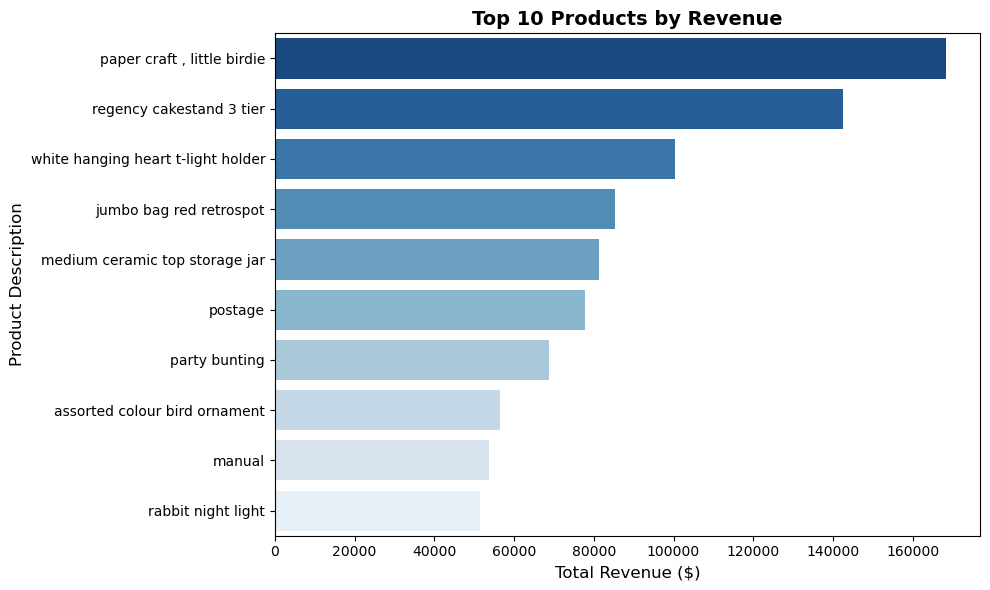

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_revenue_products.values, 
    y=top_revenue_products.index, 
    hue=top_revenue_products.index,
    palette='Blues_r',
    legend=False
)

plt.title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Product Description', fontsize=12)

plt.tight_layout()
plt.show()

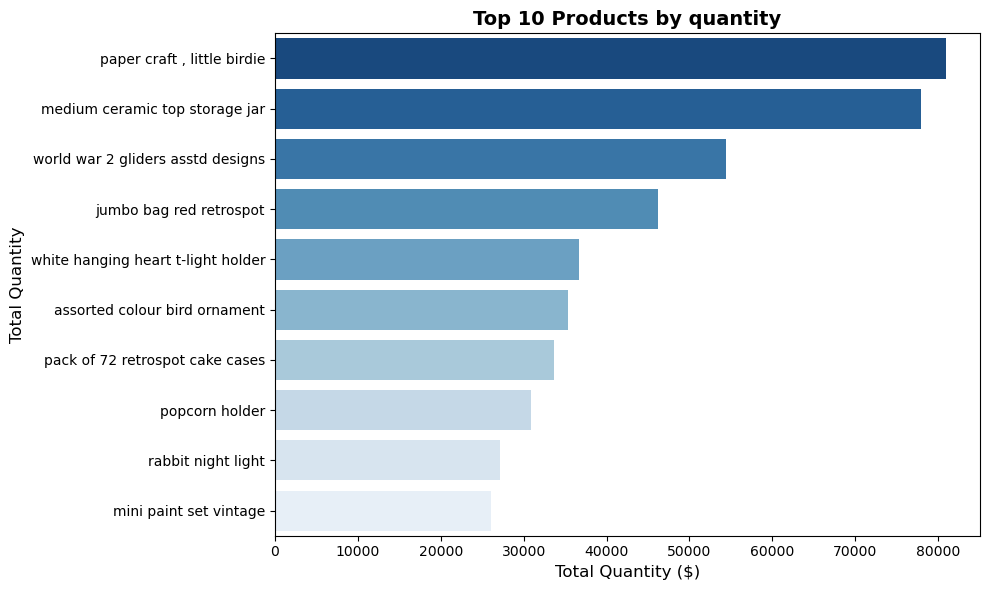

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_quantity_products.values, 
    y=top_quantity_products.index, 
    hue=top_quantity_products.index,
    palette='Blues_r',
    legend=False
)

plt.title('Top 10 Products by quantity', fontsize=14, fontweight='bold')
plt.xlabel('Total Quantity ($)', fontsize=12)
plt.ylabel('Total Quantity', fontsize=12)

plt.tight_layout()
plt.show()

### Step 3.2: Monthly Sales Trend Analysis
- Analyze revenue patterns across different months to identify seasonality.

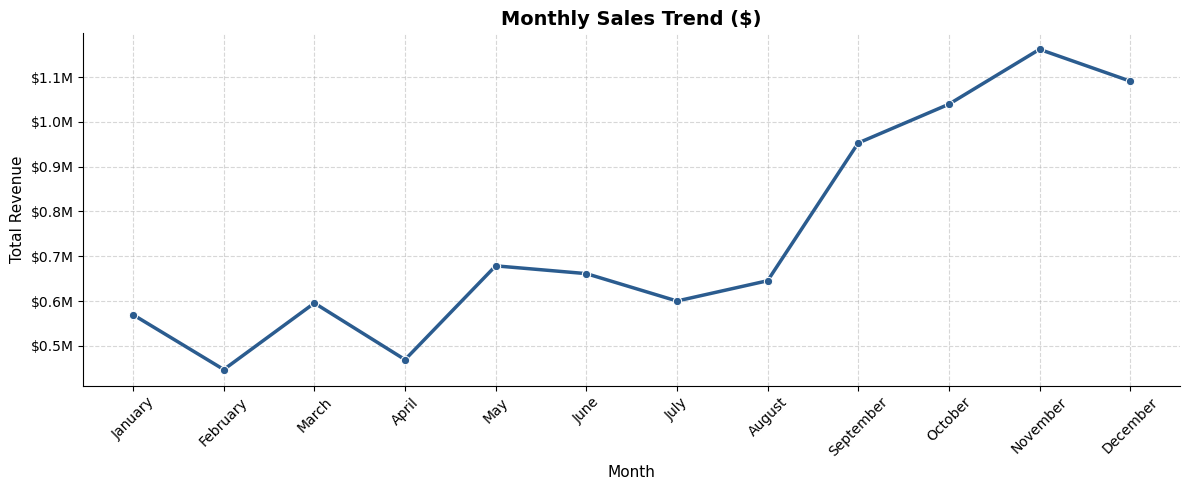

In [14]:
import matplotlib.ticker as ticker

# Group data by Month and sum TotalAmount
monthly_sales = df_clean.groupby('Month')['TotalAmount'].sum()

# Sort months chronologically
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales = monthly_sales.reindex(months_order).dropna()

# Plot line chart for monthly trend
plt.figure(figsize=(12, 5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o', color='#2b5c8f', linewidth=2.5)


formatter = ticker.FuncFormatter(lambda x, pos: f'${x*1e-6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Monthly Sales Trend ($)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=11)
plt.ylabel('Total Revenue', fontsize=11)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

sns.despine(top=True, right=True) 

plt.tight_layout()
plt.show()

### Step 3.3: Geographic Sales Distribution
- Identify top countries by revenue (excluding United Kingdom for clearer insights).

In [15]:
# Top 10 countries by revenue excluding UK
top_countries = df_clean[df_clean['Country'] != 'United Kingdom'].groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)

print("--- Top 10 International Markets (Excluding UK) ---")
print(top_countries)

--- Top 10 International Markets (Excluding UK) ---
Country
Netherlands    285446.34
EIRE           265545.90
Germany        228867.14
France         209024.05
Australia      138521.31
Spain           61577.11
Switzerland     56443.95
Belgium         41196.34
Sweden          38378.33
Japan           37416.37
Name: TotalAmount, dtype: float64


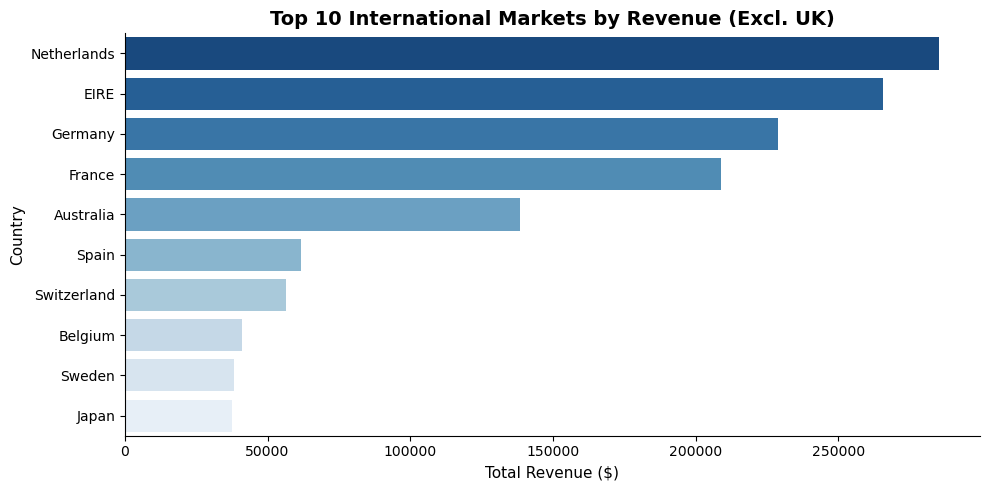

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(10, 5))

# Plot top 10 international markets
sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette='Blues_r',
    legend=False
)

plt.title('Top 10 International Markets by Revenue (Excl. UK)', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=11)
plt.ylabel('Country', fontsize=11)

sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

### Step 3.4: Order Distribution by Hour of Day
- Analyze customer purchasing behavior throughout the day to identify peak sales hours.

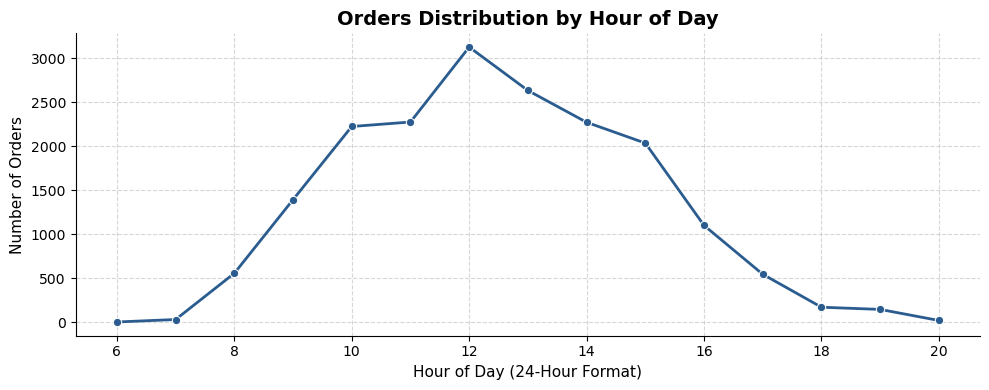

In [17]:
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour
hourly_orders = df_clean.groupby('Hour')['InvoiceNo'].nunique()

# Plot line chart for hourly trend
plt.figure(figsize=(10, 4))
sns.lineplot(x=hourly_orders.index, y=hourly_orders.values, marker='o', color='#2b5c8f', linewidth=2)

plt.title('Orders Distribution by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (24-Hour Format)', fontsize=11)
plt.ylabel('Number of Orders', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

## Phase 4: Customer Segmentation (RFM Analysis)
- Calculate Recency, Frequency, and Monetary metrics to understand customer value.

In [18]:
import datetime as dt

# Set reference date for Recency calculation (1 day after the latest invoice)
reference_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

# Calculate RFM metrics per customer
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'TotalAmount': 'sum'                                      # Monetary
}).reset_index()

# Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [19]:
# Create RFM Scores (1-4)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1]) # Lower recency is better (higher score)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

# Combine scores into a single RFM Score string
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Define Customer Segments based on RFM Scores
def segment_customer(df):
    if df['R_Score'] == 4 and df['F_Score'] == 4:
        return 'VIP / Champions'
    elif df['R_Score'] >= 3 and df['F_Score'] >= 3:
        return 'Loyal Customers'
    elif df['R_Score'] <= 2 and df['F_Score'] >= 3:
        return 'At-Risk / Need Attention'
    elif df['R_Score'] <= 2 and df['F_Score'] <= 2:
        return 'Lost Customers'
    else:
        return 'Recent / Potential'

rfm['Customer_Segment'] = rfm.apply(segment_customer, axis=1)

# Display distribution of segments
rfm['Customer_Segment'].value_counts()

Customer_Segment
Lost Customers              1504
Loyal Customers              914
Recent / Potential           665
At-Risk / Need Attention     646
VIP / Champions              609
Name: count, dtype: int64

### Step 4.2: Visualizing Customer Segments
- Plot the distribution of customers across identified RFM segments to derive actionable business insights.

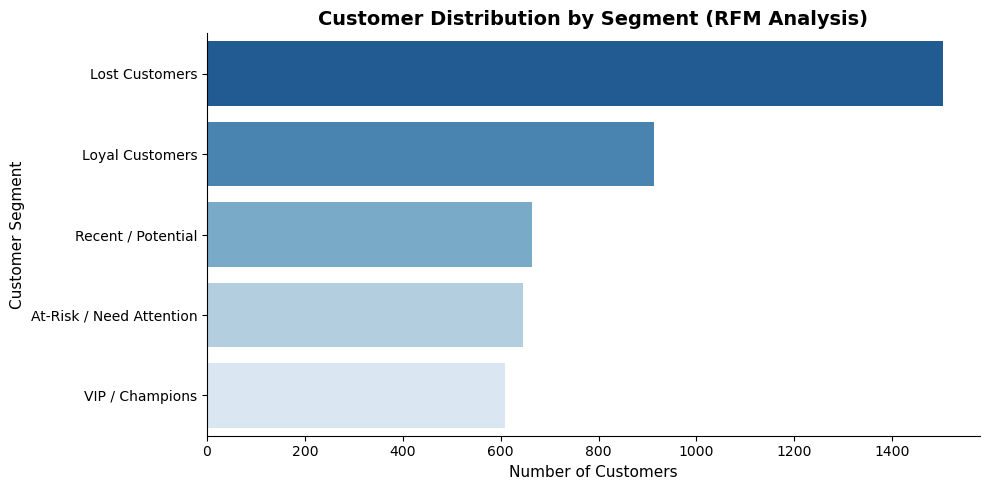

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get counts of each customer segment
segment_counts = rfm['Customer_Segment'].value_counts()

# Set figure size
plt.figure(figsize=(10, 5))

# Plot bar chart for customer segments
sns.barplot(
    x=segment_counts.values,
    y=segment_counts.index,
    hue=segment_counts.index,
    palette='Blues_r',
    legend=False
)

# Add titles and labels
plt.title('Customer Distribution by Segment (RFM Analysis)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers', fontsize=11)
plt.ylabel('Customer Segment', fontsize=11)

# Remove top and right borders
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

## Phase 5: Business Recommendations & Key Takeaways

- **Target Lost Customers:** Launch win-back email campaigns with special discount incentives to re-engage inactive accounts.
- **Reward VIP & Loyal Segment:** Introduce exclusive loyalty perks and early product access to maximize Customer Lifetime Value (CLV).
- **Optimize Marketing Timing:** Schedule marketing newsletters and promotional push notifications around peak purchasing hours (10 AM – 3 PM).
- **Focus on Top International Markets:** Expand direct shipping and localized promotions in Netherlands, EIRE, and Germany.